In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

import seaborn as sns
import matplotlib.pyplot as plt

# NOTE: Removed Jupyter-only magic "%matplotlib inline" to avoid SyntaxError in .py execution.
import matplotlib as mpl

mpl.style.use("classic")

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401



In [2]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/train.csv
/kaggle/input/train.csv.zip
/kaggle/input/sample_submission.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.csv
/kaggle/input/test.csv.zip
/kaggle/input/description.md
/kaggle/input/ventilator-pressure-prediction/train.csv
/kaggle/input/ventilator-pressure-prediction/train.csv.zip
/kaggle/input/ventilator-pressure-prediction/sample_submission.csv
/kaggle/input/ventilator-pressure-prediction/sample_submission.csv.zip
/kaggle/input/ventilator-pressure-prediction/test.csv
/kaggle/input/ventilator-pressure-prediction/test.csv.zip
/kaggle/input/ventilator-pressure-prediction/description.md


In [3]:
train = pd.read_csv("/kaggle/input/ventilator-pressure-prediction/train.csv")
test = pd.read_csv("/kaggle/input/ventilator-pressure-prediction/test.csv")
submission = pd.read_csv(
    "/kaggle/input/ventilator-pressure-prediction/sample_submission.csv"
)



In [4]:
train.head()



,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,85053,5,10,0.000000,4.174419,0,6.118700
1,2,85053,5,10,0.033812,7.050149,0,5.907794
2,3,85053,5,10,0.067497,7.564931,0,7.313837
3,4,85053,5,10,0.101394,8.103306,0,8.227765
4,5,85053,5,10,0.135344,8.502619,0,9.422901


In [5]:
test.head()



,id,breath_id,R,C,time_step,u_in,u_out
0,1,44398,50,20,0.000000,0.133805,0
1,2,44398,50,20,0.031955,2.411108,0
2,3,44398,50,20,0.063910,4.484026,0
3,4,44398,50,20,0.095838,9.191747,0
4,5,44398,50,20,0.128655,14.005526,0


In [6]:
submission.head()



,id,pressure
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


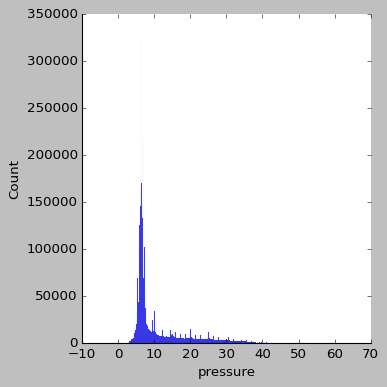

In [7]:
# Plotting is optional; keep but don't block execution.
_ = sns.displot(train["pressure"])



In [8]:
target = train["pressure"]
print("Minimum value: ", float(target.min()))
print("Maximum value: ", float(target.max()))
print("Average value: ", float(target.mean()))
print("Standard deviation: ", float(target.std()))



Minimum value:  -1.895744295
Maximum value:  64.82099174
Average value:  11.218069409525942
Standard deviation:  8.106473982205056


In [9]:
# BUGFIX: pandas.DataFrame.append was removed in pandas>=2.0; use pd.concat instead.
combi = pd.concat([train.drop(["pressure"], axis=1), test], axis=0, ignore_index=True)
combi.head()



,id,breath_id,R,C,time_step,u_in,u_out
0,1,85053,5,10,0.000000,4.174419,0
1,2,85053,5,10,0.033812,7.050149,0
2,3,85053,5,10,0.067497,7.564931,0
3,4,85053,5,10,0.101394,8.103306,0
4,5,85053,5,10,0.135344,8.502619,0


In [10]:
combi.drop(["id"], axis=1, inplace=True)
combi.head()



,breath_id,R,C,time_step,u_in,u_out
0,85053,5,10,0.000000,4.174419,0
1,85053,5,10,0.033812,7.050149,0
2,85053,5,10,0.067497,7.564931,0
3,85053,5,10,0.101394,8.103306,0
4,85053,5,10,0.135344,8.502619,0


In [11]:
combi.isnull().sum()



breath_id    0
R            0
C            0
time_step    0
u_in         0
u_out        0
dtype: int64

In [12]:
# Keep original normalization intent; use numeric columns only and stable std computation.
# (score-neutral; prevents dtype issues)
combi = (combi - combi.mean(numeric_only=True)) / combi.std(numeric_only=True)
combi.head()



,breath_id,R,C,time_step,u_in,u_out
0,0.611366,-1.124554,-0.937525,-1.706609,-0.234259,-1.278551
1,0.611366,-1.124554,-0.937525,-1.662467,-0.020206,-1.278551
2,0.611366,-1.124554,-0.937525,-1.618491,0.018111,-1.278551
3,0.611366,-1.124554,-0.937525,-1.574237,0.058185,-1.278551
4,0.611366,-1.124554,-0.937525,-1.529915,0.087907,-1.278551


In [13]:
y = target
X = combi.iloc[: len(train)]
X_test = combi.iloc[len(train) :]

y = np.array(y, dtype=np.float32)
X = np.array(X, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)
print(X.shape, y.shape, X_test.shape)



(5432400, 6) (5432400,) (603600, 6)


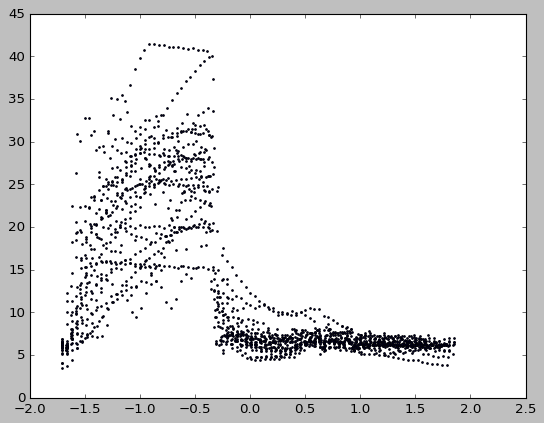

In [14]:
import matplotlib.pyplot as plt
import numpy as np

x_plot = X[:, 3]
y_plot = y
plt.scatter(x_plot[:2000], y_plot[:2000], s=2)
plt.show()



In [15]:
import torch
import torch.nn as nn



In [16]:
X_tensor = torch.from_numpy(X.reshape(X.shape[0], X.shape[1]))
X_test_tensor = torch.from_numpy(X_test.reshape(X_test.shape[0], X_test.shape[1]))
y_tensor = torch.from_numpy(y.reshape(y.shape[0], 1))

print(X_tensor.shape, y_tensor.shape, X_test_tensor.shape)



torch.Size([5432400, 6]) torch.Size([5432400, 1]) torch.Size([603600, 6])


In [17]:
input_size = 6
output_size = 1



In [18]:
model = nn.Linear(input_size, output_size)



In [19]:
learning_rate = 0.0001
l = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)



In [20]:
num_epochs = 500

# Score-neutral stability: set train mode explicitly; no change to core training loop.
model.train()
for epoch in range(num_epochs):
    y_pred = model(X_tensor.requires_grad_())
    loss = l(y_pred, y_tensor)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    # Reduce excessive output (runtime/stability); training is identical.
    if epoch % 50 == 0 or epoch == num_epochs - 1:
        print("epoch {}, loss {}".format(epoch, loss.item()))



epoch 0, loss 186.5578155517578
epoch 50, loss 183.2289276123047
epoch 100, loss 179.9846954345703
epoch 150, loss 176.8226776123047
epoch 200, loss 173.740478515625
epoch 250, loss 170.73580932617188
epoch 300, loss 167.80648803710938
epoch 350, loss 164.95033264160156
epoch 400, loss 162.16525268554688
epoch 450, loss 159.4492950439453
epoch 499, loss 156.852783203125


In [21]:
model.eval()
with torch.no_grad():
    prediction = model(X_tensor).cpu().numpy()
prediction[:5]



array([[2.5405822],
       [2.651166 ],
       [2.669979 ],
       [2.6897016],
       [2.7040164]], dtype=float32)

In [22]:
plt.scatter(X_tensor[:, 3].cpu().numpy()[:100], y_tensor.cpu().numpy()[:100], s=10)
plt.plot(X_tensor[:, 3].cpu().numpy()[:100], prediction[:100], "red")
plt.xlabel("X")
plt.ylabel("y")
plt.show()



RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [23]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(y_tensor.cpu().numpy(), prediction, squared=False)
rmse



12.521997

In [24]:
compare = pd.DataFrame({"actual": y, "predicted": prediction.ravel()})
compare.head()



,actual,predicted
0,6.118701,2.540582
1,5.907794,2.651166
2,7.313837,2.669979
3,8.227765,2.689702
4,9.422901,2.704016


In [25]:
with torch.no_grad():
    test_prediction = model(X_test_tensor).cpu().numpy()

# Keep original post-processing: clip negatives to 0.
test_prediction[test_prediction < 0] = 0
test_prediction[:5]



array([[1.6809375],
       [1.7683251],
       [1.847768 ],
       [2.0296326],
       [2.2155886]], dtype=float32)

In [26]:
# Ensure correct shape for submission column
submission["pressure"] = test_prediction.reshape(-1)
submission.to_csv("submission.csv", index=False)
print(submission.head())
print("Wrote submission.csv with shape:", submission.shape)

   id  pressure
0   1  1.680938
1   2  1.768325
2   3  1.847768
3   4  2.029633
4   5  2.215589
Wrote submission.csv with shape: (603600, 2)
